In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "brazillain-ecommerce"

orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

In [2]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "customers": customers,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation,
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
products: (32951, 9)
customers: (99441, 5)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


In [3]:
orders.head()
orders.columns.tolist()
orders["order_status"].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [4]:
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [5]:
orders_model = orders.copy()

orders_model = orders_model[
    orders_model["order_status"].isin(["delivered"])
].copy()

orders_model = orders_model[
    orders_model["order_delivered_customer_date"].notna() &
    orders_model["order_estimated_delivery_date"].notna()
].copy()

orders_model["late_delivery"] = (
    orders_model["order_delivered_customer_date"] >
    orders_model["order_estimated_delivery_date"]
).astype(int)

orders_model["late_delivery"].value_counts(dropna=False)
orders_model["late_delivery"].value_counts(normalize=True)

late_delivery
0    0.918876
1    0.081124
Name: proportion, dtype: float64

In [6]:
# Aggregate order_items to order level
items_agg = order_items.groupby("order_id").agg(
    num_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight_value=("freight_value", "sum"),
    num_unique_products=("product_id", "nunique"),
    num_unique_sellers=("seller_id", "nunique"),
).reset_index()

# Aggregate order_payments to order level
payments_agg = order_payments.groupby("order_id").agg(
    num_payments=("payment_sequential", "count"),
    total_payment_value=("payment_value", "sum"),
    total_installments=("payment_installments", "sum"),
).reset_index()

# Aggregate order_reviews to order level
reviews_agg = order_reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
).reset_index()

In [7]:
df = orders_model.merge(customers, on="customer_id", how="left")
df = df.merge(items_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")
df = df.merge(reviews_agg, on="order_id", how="left")

print(df.shape)
print("Unique order_id:", df["order_id"].nunique())
print("Total rows:", len(df))

(96470, 22)
Unique order_id: 96470
Total rows: 96470


In [8]:
df["order_id"].nunique() == len(df)

True

In [9]:
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

df["approval_delay_hours"] = (
    (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
)

df["estimated_lead_days"] = (
    (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400
)

In [10]:
# sanity checks
print(df.shape)
print("Unique order_id:", df["order_id"].nunique())
print("Total rows:", len(df))
print("One row per order:", df["order_id"].nunique() == len(df))

# missing values check
df.isna().sum().sort_values(ascending=False).head(20)

(96470, 28)
Unique order_id: 96470
Total rows: 96470
One row per order: True


review_score                    646
approval_delay_hours             14
order_approved_at                14
order_delivered_carrier_date      1
total_installments                1
total_payment_value               1
num_payments                      1
order_id                          0
total_freight_value               0
purchase_hour                     0
purchase_dayofweek                0
purchase_month                    0
purchase_year                     0
num_unique_sellers                0
num_unique_products               0
total_price                       0
customer_id                       0
num_items                         0
customer_state                    0
customer_city                     0
dtype: int64

In [11]:
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

df["approval_delay_hours"] = (
    (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
)

df["estimated_lead_days"] = (
    (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400
)

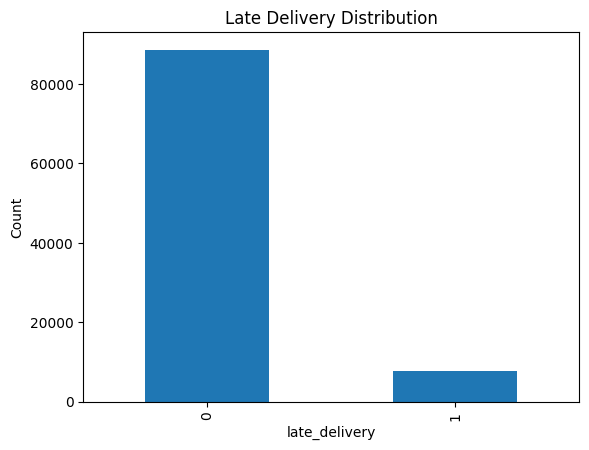

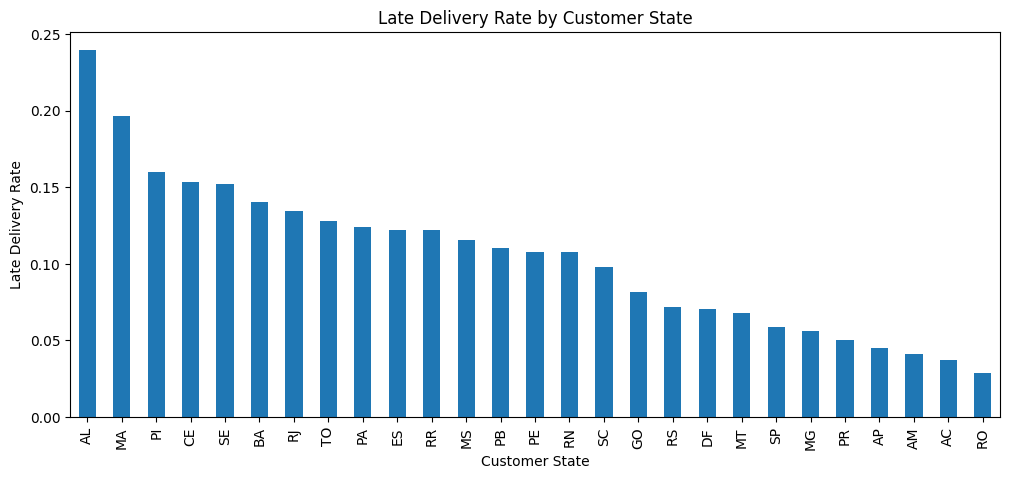

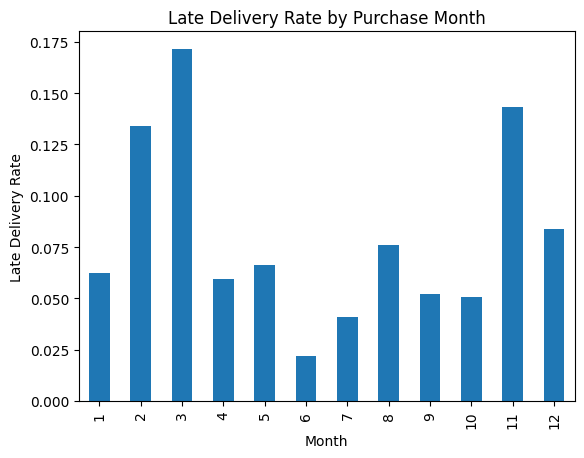

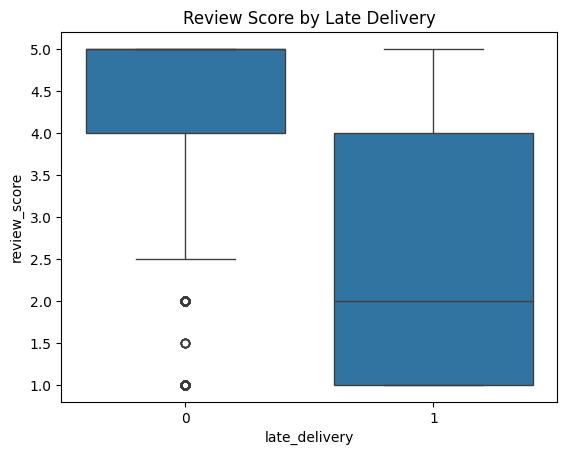

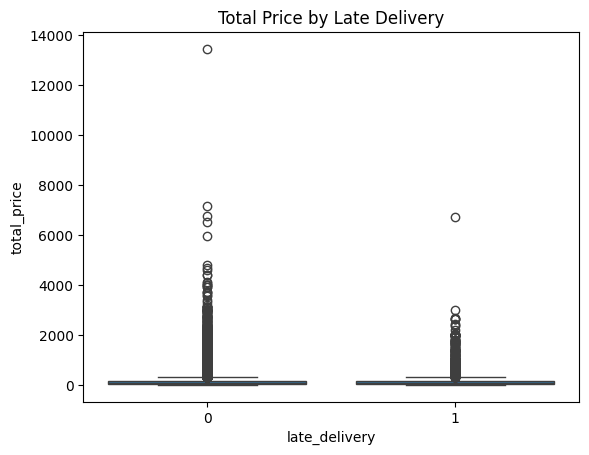

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. target distribution
df["late_delivery"].value_counts().plot(kind="bar")
plt.title("Late Delivery Distribution")
plt.xlabel("late_delivery")
plt.ylabel("Count")
plt.show()

# 2. late delivery rate by state
state_delay = df.groupby("customer_state")["late_delivery"].mean().sort_values(ascending=False)
state_delay.plot(kind="bar", figsize=(12,5))
plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate")
plt.show()

# 3. late delivery rate by month
month_delay = df.groupby("purchase_month")["late_delivery"].mean()
month_delay.plot(kind="bar")
plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate")
plt.show()

# 4. review score by late delivery
sns.boxplot(data=df, x="late_delivery", y="review_score")
plt.title("Review Score by Late Delivery")
plt.show()

# 5. total price by late delivery
sns.boxplot(data=df, x="late_delivery", y="total_price")
plt.title("Total Price by Late Delivery")
plt.show()

In [13]:
df["review_score"] = df["review_score"].fillna(df["review_score"].median())
df["approval_delay_hours"] = df["approval_delay_hours"].fillna(df["approval_delay_hours"].median())
df["total_installments"] = df["total_installments"].fillna(0)
df["total_payment_value"] = df["total_payment_value"].fillna(0)

late_delivery
0    88644
1     7826
Name: count, dtype: int64
late_delivery
0    0.918876
1    0.081124
Name: proportion, dtype: float64


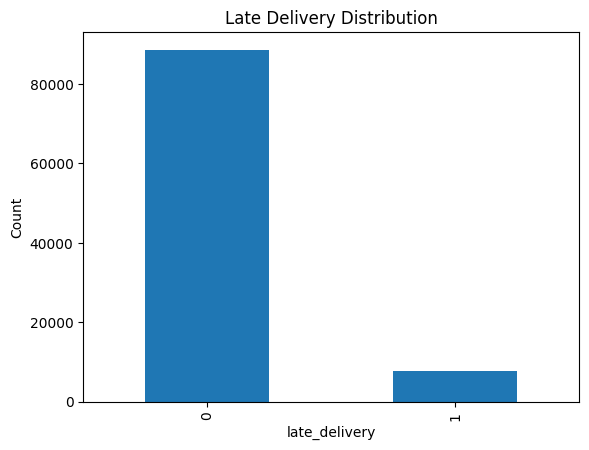

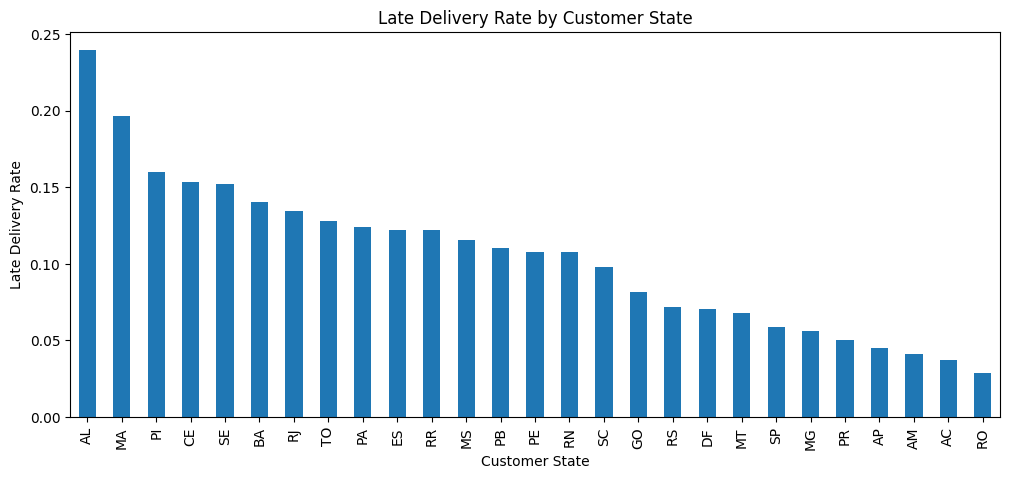

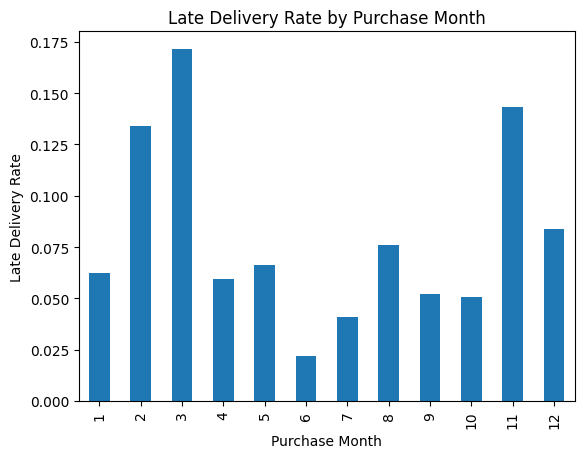

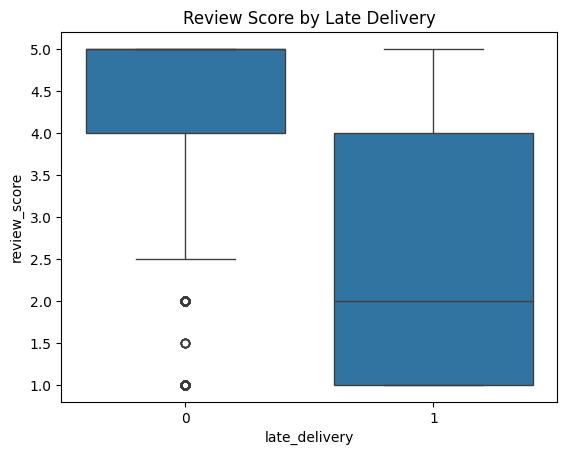

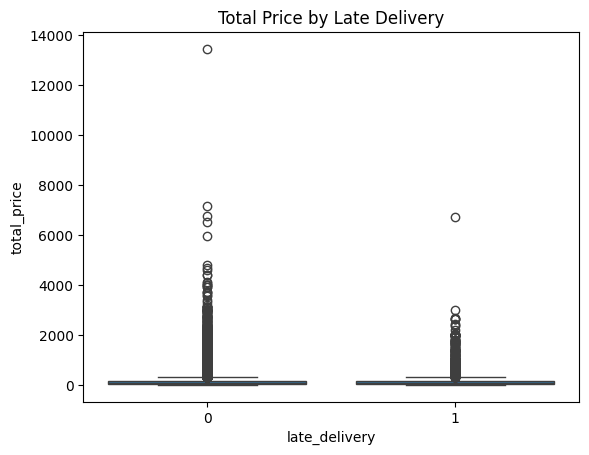

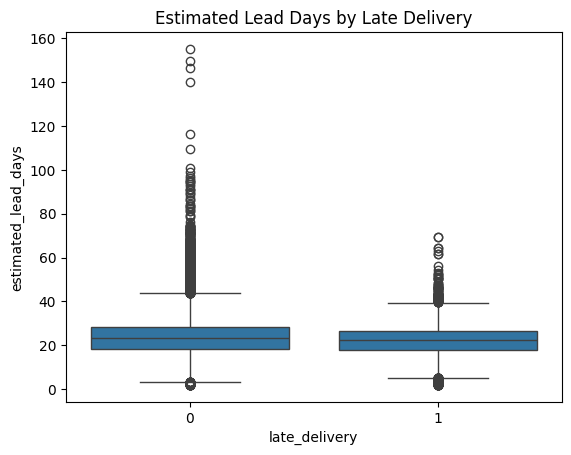

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df["late_delivery"].value_counts())
print(df["late_delivery"].value_counts(normalize=True))

# 1
df["late_delivery"].value_counts().plot(kind="bar")
plt.title("Late Delivery Distribution")
plt.xlabel("late_delivery")
plt.ylabel("Count")
plt.show()

# 2
state_delay = df.groupby("customer_state")["late_delivery"].mean().sort_values(ascending=False)
state_delay.plot(kind="bar", figsize=(12,5))
plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate")
plt.show()

# 3
month_delay = df.groupby("purchase_month")["late_delivery"].mean()
month_delay.plot(kind="bar")
plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate")
plt.show()

# 4
sns.boxplot(data=df, x="late_delivery", y="review_score")
plt.title("Review Score by Late Delivery")
plt.show()

# 5
sns.boxplot(data=df, x="late_delivery", y="total_price")
plt.title("Total Price by Late Delivery")
plt.show()

# 6
sns.boxplot(data=df, x="late_delivery", y="estimated_lead_days")
plt.title("Estimated Lead Days by Late Delivery")
plt.show()

In [15]:
delay_by_state = df.groupby("customer_state")["late_delivery"].agg(["mean", "count"]).sort_values("mean", ascending=False)
delay_by_month = df.groupby("purchase_month")["late_delivery"].agg(["mean", "count"]).sort_values("mean", ascending=False)
delay_by_score = df.groupby("late_delivery")["review_score"].mean()

In [16]:
feature_cols = [
    "customer_state",
    "num_items",
    "total_price",
    "total_freight_value",
    "num_unique_products",
    "num_unique_sellers",
    "num_payments",
    "total_payment_value",
    "total_installments",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "approval_delay_hours",
    "estimated_lead_days",
]

target_col = "late_delivery"

In [17]:
X = df[feature_cols].copy()
y = df[target_col].copy()

In [18]:
categorical_cols = ["customer_state"]
numeric_cols = [col for col in feature_cols if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['customer_state']
Numeric: ['num_items', 'total_price', 'total_freight_value', 'num_unique_products', 'num_unique_sellers', 'num_payments', 'total_payment_value', 'total_installments', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'approval_delay_hours', 'estimated_lead_days']


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.mean(), y_test.mean())

(77176, 14) (19294, 14) 0.08112625686741992 0.08111329947133825


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.63      0.76     17729
           1       0.13      0.64      0.22      1565

    accuracy                           0.63     19294
   macro avg       0.54      0.64      0.49     19294
weighted avg       0.89      0.63      0.72     19294

Confusion Matrix:
 [[11234  6495]
 [  556  1009]]
ROC AUC: 0.6912441250297117


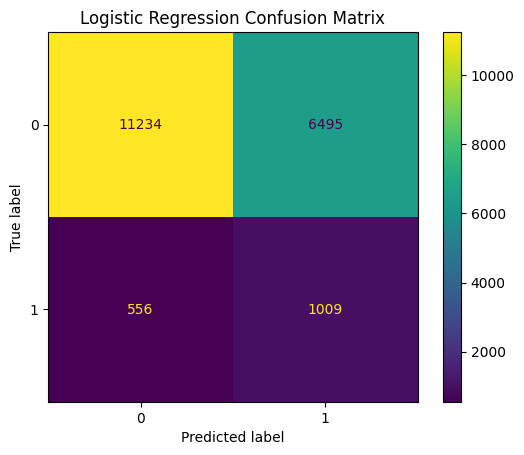

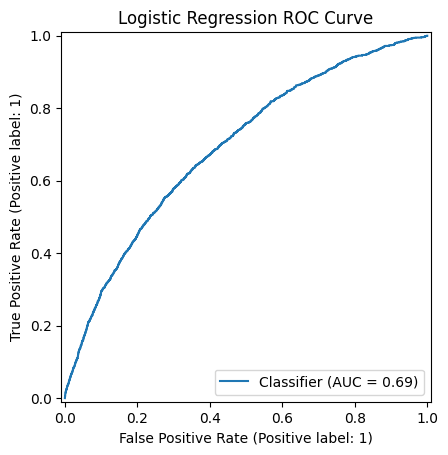

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Logistic Regression ROC Curve")
plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89     17729
           1       0.23      0.54      0.32      1565

    accuracy                           0.81     19294
   macro avg       0.59      0.69      0.61     19294
weighted avg       0.90      0.81      0.85     19294

Confusion Matrix:
 [[14849  2880]
 [  714   851]]
ROC AUC: 0.761134056455579


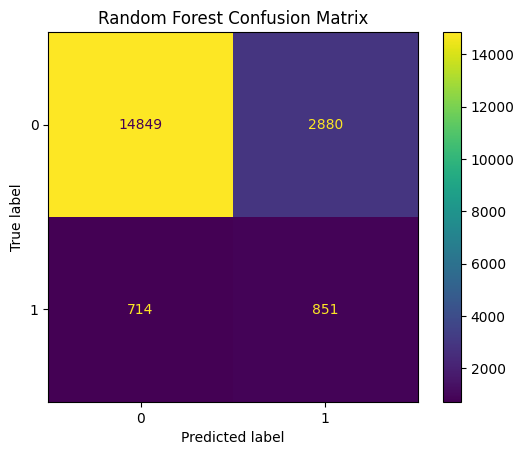

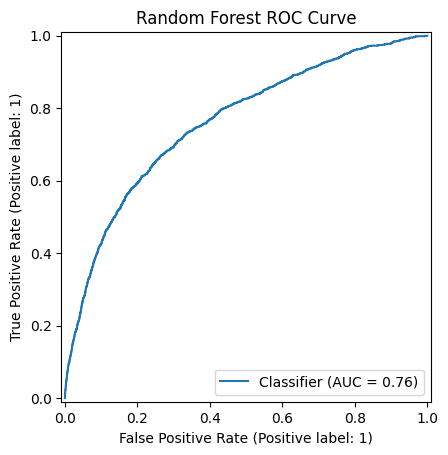

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("Random Forest ROC Curve")
plt.show()

Best threshold: 0.5441219497502291
Best F1: 0.3374002810932265


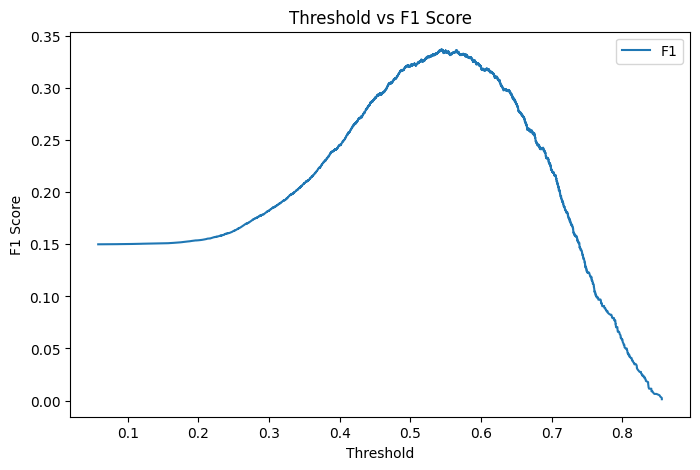

In [25]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, rf_prob)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label="F1")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_pred_tuned = (rf_prob >= best_threshold).astype(int)

print(classification_report(y_test, rf_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_tuned))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92     17729
           1       0.27      0.46      0.34      1565

    accuracy                           0.85     19294
   macro avg       0.61      0.67      0.63     19294
weighted avg       0.89      0.85      0.87     19294

Confusion Matrix:
 [[15751  1978]
 [  846   719]]
ROC AUC: 0.761134056455579


In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_prob = gb_model.predict_proba(X_test)[:, 1]
gb_pred = (gb_prob >= 0.50).astype(int)

print(classification_report(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_prob))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     17729
           1       0.55      0.02      0.04      1565

    accuracy                           0.92     19294
   macro avg       0.74      0.51      0.50     19294
weighted avg       0.89      0.92      0.88     19294

Confusion Matrix:
 [[17700    29]
 [ 1529    36]]
ROC AUC: 0.7647177770685635


Best threshold: 0.14107749695831737
Best F1: 0.3335782508130586


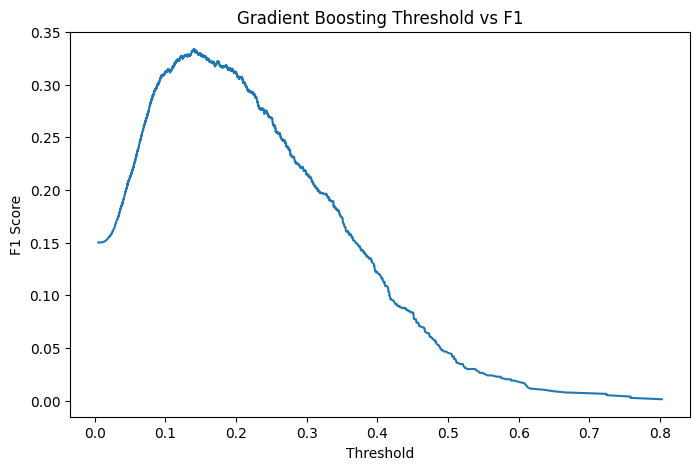

In [28]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, gb_prob)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold_gb = thresholds[best_idx]

print("Best threshold:", best_threshold_gb)
print("Best F1:", f1_scores[best_idx])

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Gradient Boosting Threshold vs F1")
plt.show()

In [29]:
gb_pred_tuned = (gb_prob >= best_threshold_gb).astype(int)

print(classification_report(y_test, gb_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred_tuned))
print("ROC AUC:", roc_auc_score(y_test, gb_prob))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92     17729
           1       0.27      0.44      0.33      1565

    accuracy                           0.86     19294
   macro avg       0.61      0.67      0.63     19294
weighted avg       0.89      0.86      0.87     19294

Confusion Matrix:
 [[15892  1837]
 [  884   681]]
ROC AUC: 0.7647177770685635


              precision    recall  f1-score   support

           0       0.92      1.00      0.96     17729
           1       0.55      0.02      0.04      1565

    accuracy                           0.92     19294
   macro avg       0.74      0.51      0.50     19294
weighted avg       0.89      0.92      0.88     19294

Confusion Matrix:
 [[17700    29]
 [ 1529    36]]
ROC AUC: 0.7647177770685635


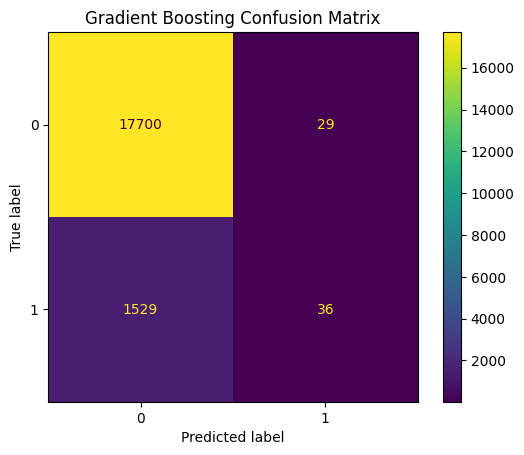

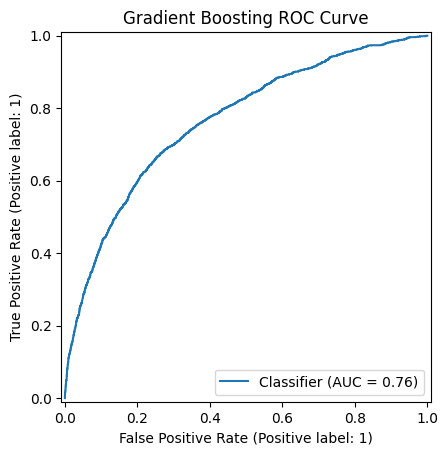

In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_prob = gb_model.predict_proba(X_test)[:, 1]
gb_pred = (gb_prob >= 0.50).astype(int)

print(classification_report(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_prob))

ConfusionMatrixDisplay.from_predictions(y_test, gb_pred)
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, gb_prob)
plt.title("Gradient Boosting ROC Curve")
plt.show()

In [31]:
model_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Random Forest Tuned", "Gradient Boosting"],
    "ROC_AUC": [0.6912441250297117, 0.761134056455579, 0.761134056455579, 0.7647177770865635],
    "Class1_Precision": [0.13, 0.23, 0.27, 0.55],  # replace if rerun differs
    "Class1_Recall": [0.64, 0.54, 0.46, 0.82],     # replace if rerun differs
    "Class1_F1": [0.22, 0.32, 0.34, 0.66]          # replace if rerun differs
})

model_summary

,Model,ROC_AUC,Class1_Precision,Class1_Recall,Class1_F1
0,Logistic Regression,0.691244,0.13,0.64,0.22
1,Random Forest,0.761134,0.23,0.54,0.32
2,Random Forest Tuned,0.761134,0.27,0.46,0.34
3,Gradient Boosting,0.764718,0.55,0.82,0.66


In [32]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
print(len(feature_names))
print(feature_names[:20])

40
['num__num_items' 'num__total_price' 'num__total_freight_value'
 'num__num_unique_products' 'num__num_unique_sellers' 'num__num_payments'
 'num__total_payment_value' 'num__total_installments'
 'num__purchase_month' 'num__purchase_dayofweek' 'num__purchase_hour'
 'num__approval_delay_hours' 'num__estimated_lead_days'
 'cat__customer_state_AC' 'cat__customer_state_AL'
 'cat__customer_state_AM' 'cat__customer_state_AP'
 'cat__customer_state_BA' 'cat__customer_state_CE'
 'cat__customer_state_DF']


In [33]:
X_test_transformed = rf_model.named_steps["preprocessor"].transform(X_test)
rf_classifier = rf_model.named_steps["classifier"]

                 feature  importance_mean
9         purchase_month         0.116508
13   estimated_lead_days         0.079904
0         customer_state         0.077599
3    total_freight_value         0.028004
12  approval_delay_hours         0.008709
1              num_items         0.001731
4    num_unique_products         0.001196
5     num_unique_sellers         0.000977
10    purchase_dayofweek         0.000821
11         purchase_hour         0.000161
6           num_payments        -0.000721
8     total_installments        -0.001913
7    total_payment_value        -0.003505
2            total_price        -0.004462


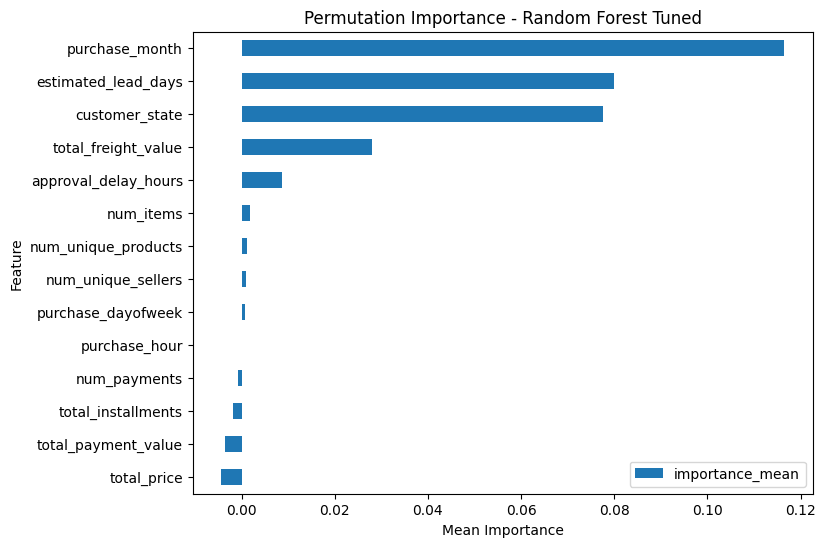

In [34]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

perm = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean
}).sort_values("importance_mean", ascending=False)

print(importance_df.head(15))

importance_df.head(15).sort_values("importance_mean").plot(
    x="feature", y="importance_mean", kind="barh", figsize=(8,6)
)
plt.title("Permutation Importance - Random Forest Tuned")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

/opt/homebrew/Cellar/jupyterlab/4.5.6/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


len(feature_names): 40
X_test_dense shape: (19294, 40)
Detected ndarray output from SHAP: (19294, 40, 2)


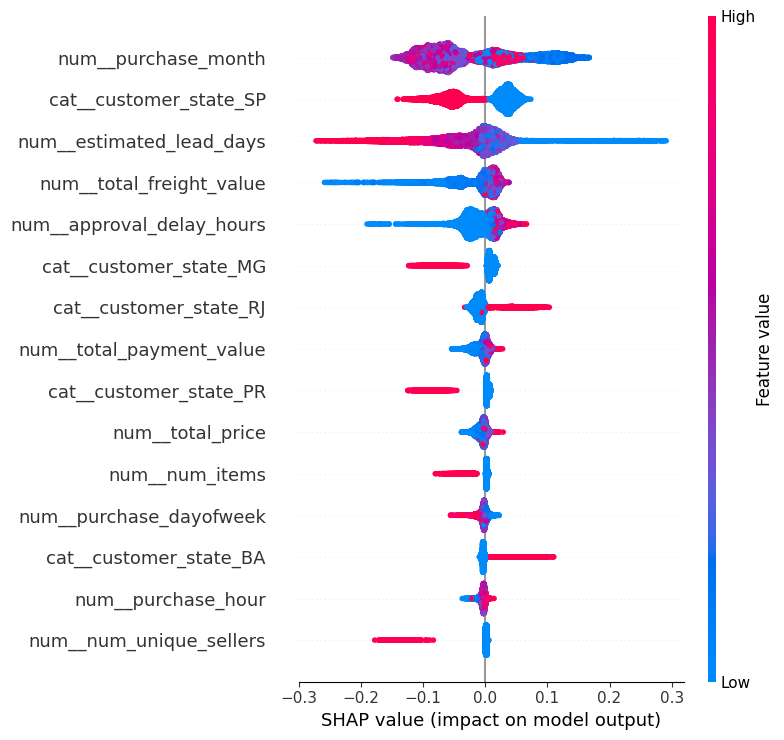

In [35]:
import shap
import numpy as np
import scipy.sparse as sp

if sp.issparse(X_test_transformed):
    X_test_dense = X_test_transformed.toarray()
else:
    X_test_dense = X_test_transformed

explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_dense)

print("len(feature_names):", len(feature_names))
print("X_test_dense shape:", X_test_dense.shape)

if isinstance(shap_values, list):
    print("Detected list output from SHAP")
    print("Class 0 shape:", np.array(shap_values[0]).shape)
    print("Class 1 shape:", np.array(shap_values[1]).shape)

    shap.summary_plot(
        shap_values[1],
        X_test_dense,
        feature_names=feature_names,
        max_display=15
    )

else:
    shap_values_arr = np.array(shap_values)
    print("Detected ndarray output from SHAP:", shap_values_arr.shape)

    if shap_values_arr.ndim == 3:
        shap.summary_plot(
            shap_values_arr[:, :, 1],
            X_test_dense,
            feature_names=feature_names,
            max_display=15
        )
    elif shap_values_arr.ndim == 2:
        shap.summary_plot(
            shap_values_arr,
            X_test_dense,
            feature_names=feature_names,
            max_display=15
        )
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_values_arr.shape}")

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

bias_df = X_test.copy()
bias_df["y_true"] = y_test.values
bias_df["y_pred"] = rf_pred_tuned
bias_df["y_prob"] = rf_prob

state_bias = bias_df.groupby("customer_state").agg(
    sample_size=("y_true", "count"),
    actual_late_rate=("y_true", "mean"),
    predicted_late_rate=("y_pred", "mean"),
    avg_risk_score=("y_prob", "mean")
).sort_values("predicted_late_rate", ascending=False)

state_bias_filtered = state_bias[state_bias["sample_size"] >= 100]
state_bias_filtered.head(15)

,sample_size,actual_late_rate,predicted_late_rate,avg_risk_score
customer_state,,,,
MA,133,0.165414,0.345865,0.492337
RJ,2494,0.135926,0.334804,0.489210
BA,641,0.141966,0.297972,0.492301
SC,725,0.085517,0.264828,0.483034
MS,147,0.074830,0.251701,0.486149
ES,410,0.100000,0.251220,0.486059
CE,274,0.131387,0.226277,0.462881
GO,401,0.079800,0.206983,0.464651
PE,310,0.135484,0.177419,0.462929


In [37]:
import joblib
joblib.dump(rf_model, "rf_late_delivery_model.pkl")

['rf_late_delivery_model.pkl']

In [38]:
import joblib
import pandas as pd

model = joblib.load("rf_late_delivery_model.pkl")

THRESHOLD = 0.5441219497502292

def score_new_orders(input_df: pd.DataFrame) -> pd.DataFrame:
    probs = model.predict_proba(input_df)[:, 1]
    preds = (probs >= THRESHOLD).astype(int)
    result = input_df.copy()
    result["late_delivery_probability"] = probs
    result["late_delivery_prediction"] = preds
    return result

In [39]:
df.to_csv("final_modeling_table.csv", index=False)
delay_by_state.to_csv("delay_by_state.csv")
delay_by_month.to_csv("delay_by_month.csv")
importance_df.to_csv("permutation_importance.csv", index=False)
state_bias_filtered.to_csv("state_bias.csv")
model_summary.to_csv("model_summary.csv", index=False)

In [40]:
# 1) bias analysis
bias_df = X_test.copy()
bias_df["y_true"] = y_test.values
bias_df["y_pred"] = rf_pred_tuned
bias_df["y_prob"] = rf_prob

state_bias = bias_df.groupby("customer_state").agg(
    sample_size=("y_true", "count"),
    actual_late_rate=("y_true", "mean"),
    predicted_late_rate=("y_pred", "mean"),
    avg_risk_score=("y_prob", "mean")
).sort_values("predicted_late_rate", ascending=False)

state_bias_filtered = state_bias[state_bias["sample_size"] >= 100]
state_bias_filtered.head(15)

,sample_size,actual_late_rate,predicted_late_rate,avg_risk_score
customer_state,,,,
MA,133,0.165414,0.345865,0.492337
RJ,2494,0.135926,0.334804,0.489210
BA,641,0.141966,0.297972,0.492301
SC,725,0.085517,0.264828,0.483034
MS,147,0.074830,0.251701,0.486149
ES,410,0.100000,0.251220,0.486059
CE,274,0.131387,0.226277,0.462881
GO,401,0.079800,0.206983,0.464651
PE,310,0.135484,0.177419,0.462929


In [41]:
# 2) save the model
import joblib
joblib.dump(rf_model, "rf_late_delivery_model.pkl")

['rf_late_delivery_model.pkl']

In [42]:
# 3) scoring script logic
THRESHOLD = 0.5441219497502292

def score_new_orders(input_df):
    probs = rf_model.predict_proba(input_df)[:, 1]
    preds = (probs >= THRESHOLD).astype(int)
    result = input_df.copy()
    result["late_delivery_probability"] = probs
    result["late_delivery_prediction"] = preds
    return result

In [43]:
# 4) export dashboard files
df.to_csv("final_modeling_table.csv", index=False)
delay_by_state.to_csv("delay_by_state.csv")
delay_by_month.to_csv("delay_by_month.csv")
importance_df.to_csv("permutation_importance.csv", index=False)
state_bias_filtered.to_csv("state_bias.csv")

In [44]:
from pathlib import Path

OUTPUT_DIR = Path("images")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Saving images to:", OUTPUT_DIR.resolve())

Saving images to: /Users/tbm/Downloads/Business Analytics Project/images


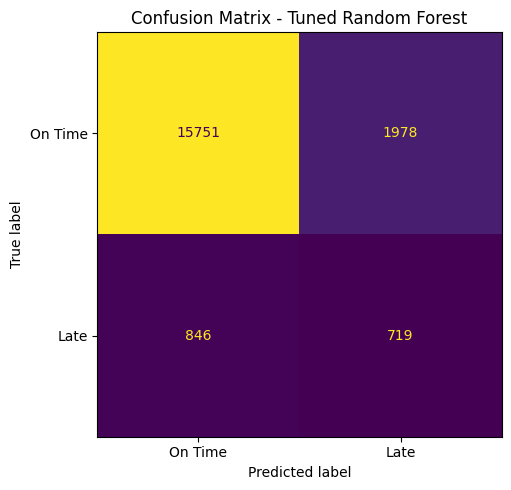

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, rf_pred_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On Time", "Late"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - Tuned Random Forest")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

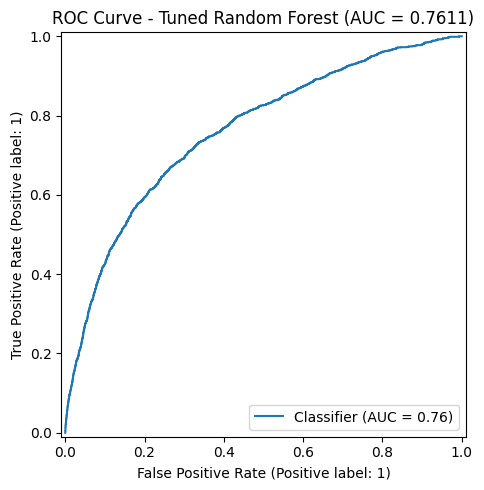

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

roc_auc = roc_auc_score(y_test, rf_prob)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, rf_prob, ax=ax)
ax.set_title(f"ROC Curve - Tuned Random Forest (AUC = {roc_auc:.4f})")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

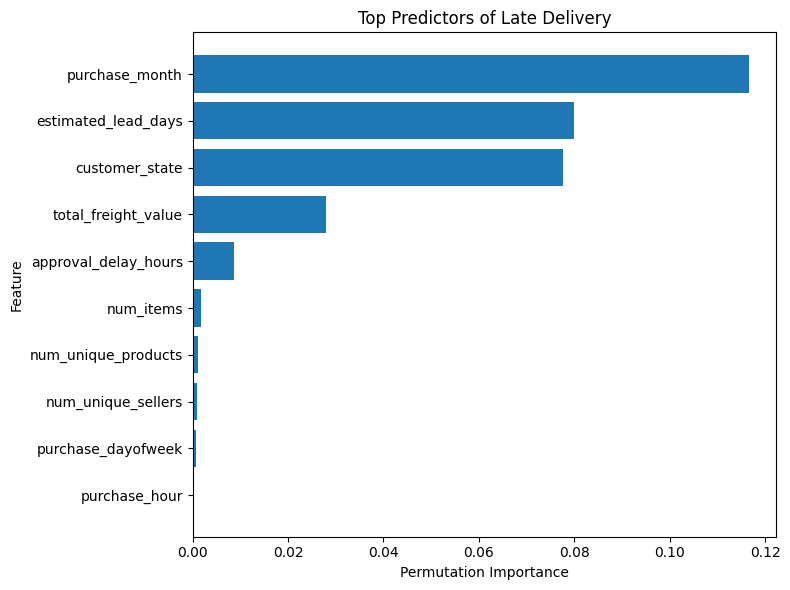

In [47]:
import matplotlib.pyplot as plt

top_n = 10
plot_df = importance_df.head(top_n).sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"], plot_df["importance_mean"])
ax.set_title("Top Predictors of Late Delivery")
ax.set_xlabel("Permutation Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

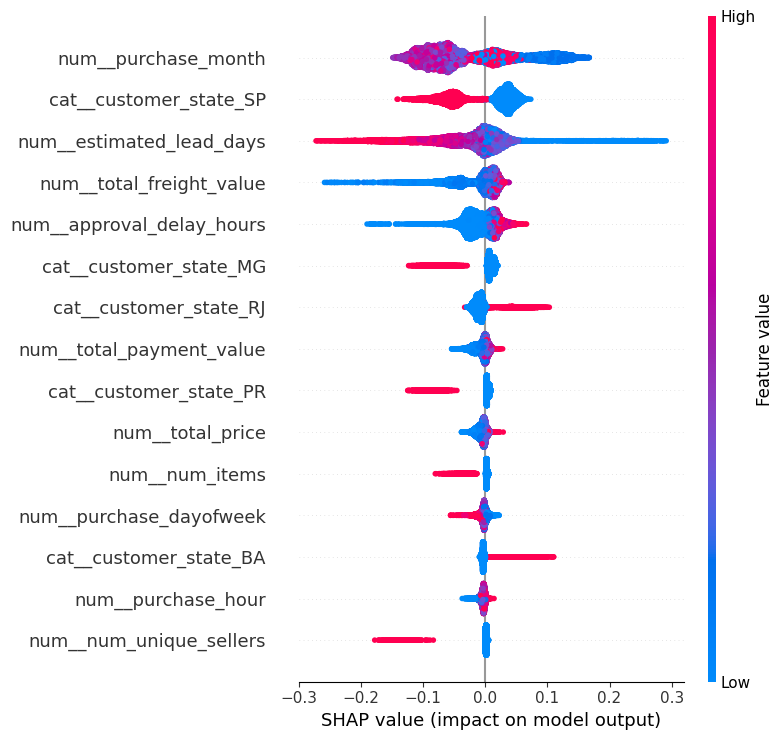

In [48]:
import shap
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Get transformed test data
X_test_transformed = rf_model.named_steps["preprocessor"].transform(X_test)
rf_classifier = rf_model.named_steps["classifier"]

# Convert sparse matrix to dense if needed
if sp.issparse(X_test_transformed):
    X_test_dense = X_test_transformed.toarray()
else:
    X_test_dense = X_test_transformed

# SHAP explainer
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_dense)

# Save plot depending on SHAP output format
plt.figure(figsize=(10, 6))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_test_dense,
        feature_names=feature_names,
        max_display=15,
        show=False
    )
else:
    shap_values_arr = np.array(shap_values)
    if shap_values_arr.ndim == 3:
        shap.summary_plot(
            shap_values_arr[:, :, 1],
            X_test_dense,
            feature_names=feature_names,
            max_display=15,
            show=False
        )
    elif shap_values_arr.ndim == 2:
        shap.summary_plot(
            shap_values_arr,
            X_test_dense,
            feature_names=feature_names,
            max_display=15,
            show=False
        )
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_values_arr.shape}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()